# German Credit Dataset Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('GermanCredit.csv')
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,'<0',6,'critical/other existing credit',radio/tv,1169,'no known savings','>=7',4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,'0<=X<200',48,'existing paid',radio/tv,5951,'<100','1<=X<4',2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,'<100','4<=X<7',2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,'<0',42,'existing paid',furniture/equipment,7882,'<100','4<=X<7',2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,'<0',24,'delayed previously','new car',4870,'<100','1<=X<4',3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


## Preprocessing

### 1. Drop 3 columns with most 'none' values

In [3]:
def drop_most_none_columns(df, n=3):
    none_counts = (df == 'none').sum()
    cols_to_drop = (none_counts[none_counts > 0]
                    .sort_values(ascending=False)
                    .head(n)
                    .index.tolist())
    print(f"Dropping columns: {cols_to_drop}")
    return df.drop(columns=cols_to_drop)

df = drop_most_none_columns(df, n=3)
df.head()

Dropping columns: ['other_parties', 'other_payment_plans', 'own_telephone']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,residence_since,property_magnitude,age,housing,existing_credits,job,num_dependents,foreign_worker,class
0,'<0',6,'critical/other existing credit',radio/tv,1169,'no known savings','>=7',4,'male single',4,'real estate',67,own,2,skilled,1,yes,good
1,'0<=X<200',48,'existing paid',radio/tv,5951,'<100','1<=X<4',2,'female div/dep/mar',2,'real estate',22,own,1,skilled,1,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,'<100','4<=X<7',2,'male single',3,'real estate',49,own,1,'unskilled resident',2,yes,good
3,'<0',42,'existing paid',furniture/equipment,7882,'<100','4<=X<7',2,'male single',4,'life insurance',45,'for free',1,skilled,2,yes,good
4,'<0',24,'delayed previously','new car',4870,'<100','1<=X<4',3,'male single',4,'no known property',53,'for free',2,skilled,2,yes,bad


### 2. Remove apostrophes

In [4]:
df = df.map(lambda x: x.replace("'", "") if isinstance(x, str) else x)
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,residence_since,property_magnitude,age,housing,existing_credits,job,num_dependents,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,4,real estate,67,own,2,skilled,1,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,2,real estate,22,own,1,skilled,1,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,3,real estate,49,own,1,unskilled resident,2,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,4,life insurance,45,for free,1,skilled,2,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,4,no known property,53,for free,2,skilled,2,yes,bad


### 3. Map checking_status

In [5]:
checking_map = {
    'no checking': 'No Checking',
    '<0':          'Low',
    '0<=X<200':    'Medium',
    '>=200':       'High'
}
df['checking_status'] = df['checking_status'].map(checking_map)
df['checking_status'].value_counts()

checking_status
No Checking    394
Low            274
Medium         269
High            63
Name: count, dtype: int64

### 4. Map savings_status

In [6]:
savings_map = {
    'no known savings': 'No Savings',
    '<100':             'Low',
    '100<=X<500':       'Medium',
    '500<=X<1000':      'High',
    '>=1000':           'High'
}
df['savings_status'] = df['savings_status'].map(savings_map)
df['savings_status'].value_counts()

savings_status
Low           603
No Savings    183
High          111
Medium        103
Name: count, dtype: int64

### 5. Map class: good→1, bad→0

In [7]:
df['class'] = df['class'].map({'good': '1', 'bad': '0'})
df['class'].value_counts()

class
1    700
0    300
Name: count, dtype: int64

### 6. Map employment

In [8]:
employment_map = {
    'unemployed': 'Unemployed',
    '<1':         'Amateur',
    '1<=X<4':     'Amateur',
    '4<=X<7':     'Professional',
    '>=7':        'Experienced'
}
df['employment'] = df['employment'].apply(lambda x: employment_map.get(x, 'Expert'))
df['employment'].value_counts()

employment
Amateur         511
Experienced     253
Professional    174
Unemployed       62
Name: count, dtype: int64

## Analysis

### A. Crosstab: foreign_worker × class

In [9]:
df['class'] = df['class'].map({'1': 'good', '0': 'bad'})
ct1 = pd.crosstab(df['foreign_worker'], df['class'])
ct1

class,bad,good
foreign_worker,,
no,4,33
yes,296,667


### B. Crosstab: employment × savings_status

In [10]:
ct2 = pd.crosstab(df['employment'], df['savings_status'])
ct2

savings_status,High,Low,Medium,No Savings
employment,,,,
Amateur,56,330,50,75
Experienced,34,133,22,64
Professional,18,100,24,32
Unemployed,3,40,7,12


### C. Avg credit_amount: single males with Professional employment

In [11]:
mask = (df['personal_status'] == 'male single') & (df['employment'] == 'Professional')
avg_credit = df.loc[mask, 'credit_amount'].mean()
print(f"Average credit amount: {avg_credit}")

Average credit amount: 4142.592592592592


### D. Avg credit duration per job type

In [12]:
avg_duration = df.groupby('job')['duration'].mean()
avg_duration

job
high qualif/self emp/mgmt    25.168919
skilled                      21.411111
unemp/unskilled non res      17.363636
unskilled resident           16.535000
Name: duration, dtype: float64

### E. Most common checking & savings status for 'education' purpose

In [13]:
edu = df[df['purpose'] == 'education']
most_common_checking = edu['checking_status'].mode()[0]
most_common_savings  = edu['savings_status'].mode()[0]
print(f"Most common checking status: {most_common_checking}")
print(f"Most common savings status: {most_common_savings}")

Most common checking status: No Checking
Most common savings status: Low


## Visualization

### Plot 1: savings_status & checking_status vs personal_status

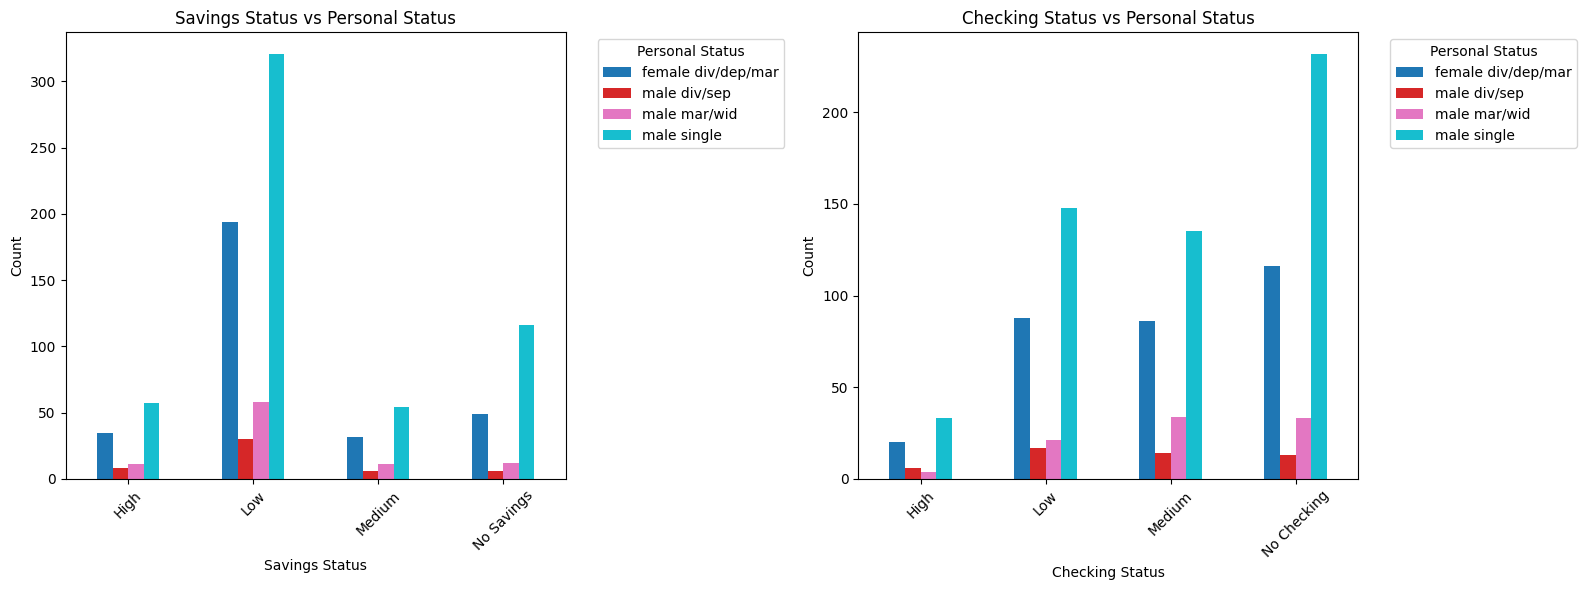

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(axes,
                           ['savings_status', 'checking_status'],
                           ['Savings Status vs Personal Status',
                            'Checking Status vs Personal Status']):
    ct = pd.crosstab(df[col], df['personal_status'])
    ct.plot(kind='bar', ax=ax, colormap='tab10')
    ax.set_title(title)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Personal Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Plot 2: Property magnitude vs avg age (credit_amount > 4000)

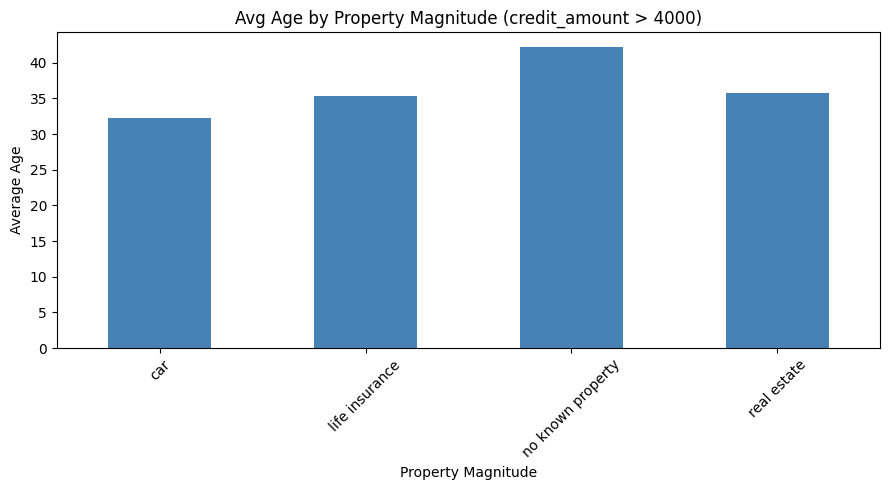

In [15]:
df_high = df[df['credit_amount'] > 4000]
avg_age_by_prop = df_high.groupby('property_magnitude')['age'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
avg_age_by_prop.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Avg Age by Property Magnitude (credit_amount > 4000)')
ax.set_xlabel('Property Magnitude')
ax.set_ylabel('Average Age')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Plot 3: Pie charts for High savings & age > 40

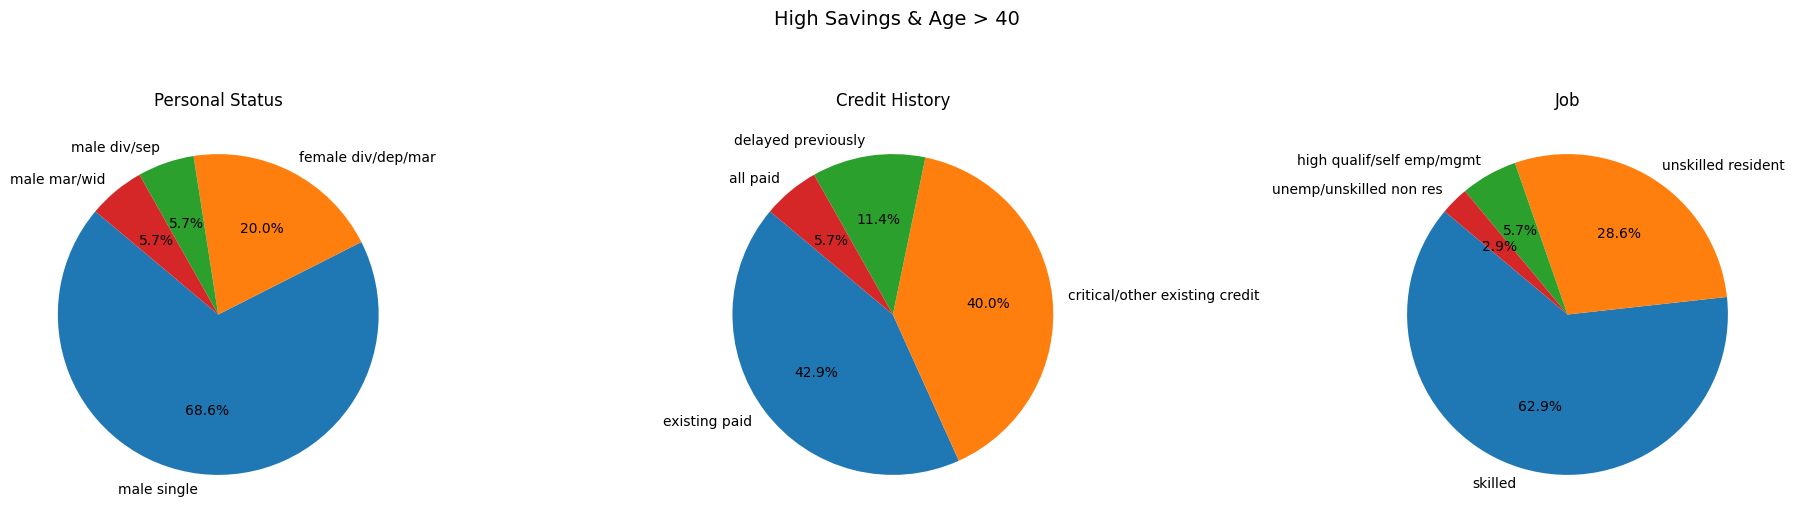

In [16]:
df_subset = df[(df['savings_status'] == 'High') & (df['age'] > 40)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pie_cols = ['personal_status', 'credit_history', 'job']
titles   = ['Personal Status', 'Credit History', 'Job']

for ax, col, title in zip(axes, pie_cols, titles):
    counts = df_subset[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    ax.set_title(title)

fig.suptitle('High Savings & Age > 40', fontsize=14)
plt.tight_layout()
plt.show()